Topic modeling is a popular method for uncovering latent themes in large
text corpora, but its outputs are not self-evidently correct. Classical
statistical methods such as regression assume a single "true"
data-generating process, so validation can ask how closely a model
approximates it. Topic modeling, as an inductive and largely unsupervised
method, makes no such assumption: there is no "correct" number of topics
or partition of a corpus waiting to be discovered, and the field does not
even agree on what "a topic" is. A model's usefulness instead depends on
its purpose. One model might suit summarizing documents and another
tracking a theme over time, even on the same corpus. A single
standardized validation metric, applied regardless of purpose, therefore
does not fit topic modeling [@bernhardharrer2026beyond].

This tutorial shows how to validate a topic model built with BERTopic
[@grootendorst2022bertopic]. It gives you hands-on practice with several
validation approaches so you can choose and justify the ones that fit
your own research question.

## Learning Objectives

By the end of this tutorial, you will be able to

1. Explain why topic model validation cannot rely on a single standardized metric, and why the choice of validation method should follow from the model's intended use.
2. Distinguish between model *selection* (narrowing down and choosing among candidate models) and model *validation* (justifying that the chosen model is fit for purpose), and explain why using the same method for both risks circular reasoning.
3. Fit a BERTopic model on a text corpus, screen a set of candidate models with automated metrics, and narrow them down to a shortlist using qualitative, human-judgment-based inspection.
4. Justify a selected topic model as valid — theoretically and methodologically — and decide, with an eye on potential bias, whether any of its topics should be merged or disregarded before it is used for further analysis.
5. Create a validation strategy for your own topic modeling project, selecting and justifying the combination of validation approaches best suited to your research question, and report that strategy transparently.

## Target audience

This tutorial is aimed at researchers and students in the social sciences with some prior experience using Python and a basic familiarity with topic modeling. No prior experience with validation methods is assumed.

## Setting up the computational environment

This tutorial's dependencies are pinned in `requirements.txt` (BERTopic, sentence-transformers, UMAP, HDBSCAN, gensim, scikit-learn, pandas, matplotlib, and pyarrow for reading the Parquet dataset). Install them with the cell below before running anything else.

In [1]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Duration

maybe half a work day, including the qualitative validation.

## Social Science Usecase(s)

Topic modeling is widely used across the social sciences, for example in
political communication, journalism studies, and migration research
(e.g., media framing of the European refugee crisis
[@heidenreich2019media]). Such applications often build or test theory,
so the validity of the topics directly affects the credibility of the
findings. This is not only a theoretical concern: applying different
validation methods to the same corpus can lead researchers to different
models and, consequently, to different substantive conclusions
[@bernhard2023topic].

## The Data

This tutorial uses the HuffPost News Category Dataset [@misra2022news], a
large collection of English-language news headlines and short descriptions
published by HuffPost between 2012 and 2018.

In [2]:
# We use pandas to read the dataset directly from Hugging Face. The data
# is stored there in Parquet format, an efficient file format for storing
# large tables, which pandas can read straight from a URL.
import pandas as pd

df = pd.read_parquet(
    "https://huggingface.co/datasets/khalidalt/HuffPost/"
    "resolve/refs%2Fconvert%2Fparquet/default/test/0000.parquet"
)

# Quick check: print the shape (rows, columns) to see how many
# articles we downloaded, and preview the first few rows to see what
# columns are available.
print(df.shape)
df.head()

(200853, 7)


,category,headline,authors,link,short_description,date,label
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26,20
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26,2
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26,2
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,Ron Dicker,https://www.huffingtonpost.com/entry/jim-carre...,The actor gives Dems an ass-kicking for not fi...,2018-05-26,2
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,Ron Dicker,https://www.huffingtonpost.com/entry/julianna-...,"The ""Dietland"" actress said using the bags is ...",2018-05-26,2


In this dataset we have the following columns available.

- `headline` — the article headline
- `short_description` — a one- to two-sentence summary of the article
- `category` — the HuffPost section the article was published under (41
  categories, e.g. `"POLITICS"`, `"SPORTS"`)
- `label` - a numerical representation of `category`
- `date` — the publication date (`YYYY-MM-DD`)
- `authors` — the article's author
- `link` — URL to the original article 

In [3]:
# BERTopic expects one string of text per document. Since each row here
# has two short text fields, we combine the headline and short description
# into a single `text` column that we'll feed into the model later.
df["text"] = df["headline"] + ". " + df["short_description"]

# The full corpus has close to 200,000 articles. Sweeping across multiple
# candidate BERTopic models on all of them would be slow, so we draw a random 
# subset of 5,000 articles instead. Setting random_state makes the sample reproducible: 
# rerunning this cell will always select the same 5,000 articles.
df = df.sample(n=5000, random_state=42).reset_index(drop=True)

# Quick check: print the shape (rows, columns) to see if the sampling worked.
print(df.shape)

(5000, 8)


## Preprocessing: Cleaning the Data

This dataset comes already deduplicated and free of empty entries, so we
skip an explicit cleaning step. How much preprocessing you need also depends on the algorithm.
BERTopic works on embeddings from a pretrained language model and needs
far less preprocessing than word-count-based methods such as LDA, which
are typically applied to lowercased, lemmatized text stripped of
stopwords, numbers, and punctuation; these choices are not neutral and
substantially affect the results [@denny2018text].

## What Do We Mean by "Validation"?

Before planning a validation strategy, it's worth being precise about what
"validation" and "validity" actually mean. In the social sciences, validity broadly asks whether a measure
captures what it claims to capture — whether a model's output can be
trusted as a fair representation of the thing you set out to study.

For more on validity frameworks relevant to topic modeling, see:
- Maier et al. [-@maier2018applying] offer a practical roadmap for
  applying and evaluating LDA topic models in communication research.
- Krippendorff [-@krippendorff2013content] covers face, social, and
  empirical validity in content analysis.
- DiMaggio et al. [-@dimaggio2013exploiting] cover statistical, semantic,
  and predictive validity for inductive text methods.

Using this taxonomy, Bernhard-Harrer and colleagues [-@bernhardharrer2026beyond] sorted the validation
practices of 789 published studies into eight categories: Model
Comparison, Internal Qualitative Inspection, External Qualitative
Inspection, Error Rate Analysis, Distinctiveness of Top Words, Information
Theory Metrics, Similarity and Distance Metrics, and Downstream Tasks.
None is inherently better than the others. Each captures a different kind
of evidence and has its own blind spots. Across two decades of
research, the field has not converged on any combination of these
categories, and it should not be expected to. Validating a topic model
means arguing that it does what your research needed. You make that
argument with the combination of categories that best fits your purpose
and report it transparently, so readers can judge it for themselves. 

For the same reason, this tutorial shows only *one* possible way to validate
a topic model, not a template to reuse unchanged for a different research
question.

## Planning a Validation Strategy

Plan the validation design before running any models. Bernhard et al.
[-@bernhard2023topic] suggest a practical starting point: first describe
what a *good* model would look like, then use that description to choose
validation methods. In practice, this means answering four questions:

1. **What would a good model look like?** In a real project, your
   research question, prior literature, and domain expertise should
   answer this. Here we have no specific research question, but we know
   the source. HuffPost is a general-interest news outlet, so we expect
   broad, recognizable topics such as politics, entertainment, sport, and
   business, mirroring a typical news outlet's sections. A good model has
   individually interpretable topics that include these themes.
2. **What evidence would show that a model meets this description?**
   We have no manually annotated ground truth, so error-rate metrics like
   precision and recall are not available for comparing candidate models.
   (For the final model, we show how to create a small annotated sample;
   see "Model Validation.") For selection, we use two kinds of evidence. Quantitative measures show whether topics are statistically
   coherent and distinct, which lets us narrow many candidate models
   down cheaply. Qualitative checks show whether the topics actually mean
   something. We read and label topics ourselves, and we compare them
   with two external reference points: the dataset's existing `category`
   labels and real-world events over time.
3. **Which methods capture that evidence?** The eight categories of
   Bernhard-Harrer et al. [-@bernhardharrer2026beyond] help make this
   choice systematic rather than arbitrary.
4. **How will selection and validation be kept apart?** Relying only on
   the evidence that picked a model to also declare it valid risks
   circular reasoning. *Selection* covers everything that narrows the
   candidates to one final model. *Validation* begins after that choice
   and builds the case for trusting that one model. It can draw on the
   expectations written down here, before any model was fit, and on new
   evidence collected only for the final model.

Following this logic, the tutorial applies:

- **Quantitative screening (Model Comparison / Information Theory
  Metrics):** NPMI and C_v coherence, topic diversity, and category
  alignment (how strongly each topic is dominated by a single existing
  `category` label), to narrow the candidates to a shortlist.
- **Topic labeling (Internal Qualitative Inspection):** reading
  representative documents and labeling each topic, to check whether the
  topics are interpretable.
- **Comparison with existing category labels (External Qualitative
  Inspection):** examining which `category` labels make up each topic.
- **Comparison with real-world events (External Qualitative
  Inspection):** checking whether topic frequency over time tracks known
  events.
- **Validation of the final model:** checking it against the ex-ante
  expectations above, and collecting new evidence through word intrusion,
  document intrusion, close reading, and manual annotation of a document
  sample (precision, recall, and F1).

## Fitting a BERTopic Model

[BERTopic](https://maartengr.github.io/BERTopic/) [@grootendorst2022bertopic] embeds each document
with a pretrained sentence model, reduces the embeddings' dimensionality
(UMAP by default), and clusters them into topics (HDBSCAN by default).
Because hyperparameters can noticeably change the results, we fit a small
grid of candidate models and vary two hyperparameters:

- `min_topic_size` (15 to 150): the minimum number of documents per topic.
  With 5,000 articles across 41 categories, smaller values fragment the
  corpus into too many topics to inspect.
- `n_neighbors` (10 vs. 30): how much local versus global structure UMAP
  preserves.

We also remove English stopwords from the topic representations. For
other parameters and representation options, see BERTopic's
[parameter tuning guide](https://maartengr.github.io/BERTopic/getting_started/parameter%20tuning/parametertuning.html)
and [representation models](https://maartengr.github.io/BERTopic/getting_started/representation/representation.html).

In [4]:
# The list of texts we'll feed into BERTopic, plus the metadata columns
# we keep aside for later: `category` (our external comparison point) and
# `date` (our time variable) -- see "Model Selection" below.
documents = df["text"].tolist()
metadata = df[["category", "date"]].reset_index(drop=True)

**Note: This step is computationally expensive.** Fitting twelve
candidate models can be slow or infeasible without a GPU or with limited
memory. All twelve models are already fit and saved in the
`candidate_models/` folder of this tutorial's GitHub repository, so by
default the cell below skips fitting, and the saved models are loaded at
the start of "Model Selection." Set `FIT_MODELS = True` to fit them
yourself.
The document embeddings, the slowest part, are also only computed in that
case.

In [5]:
from umap import UMAP
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import os

# The fitted models are provided in `candidate_models/`, so fitting is off
# by default. Set to True to fit and save the models yourself.
FIT_MODELS = False

if FIT_MODELS:
    from sentence_transformers import SentenceTransformer

    # Load a pretrained sentence embedding model. "all-MiniLM-L6-v2" is a
    # small, fast model that turns each document into a 384-dimensional
    # vector capturing its meaning.
    embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

    # Compute the embeddings once and reuse them for every candidate model.
    embeddings = embedding_model.encode(documents, show_progress_bar=True)

    # The two hyperparameters we vary (see the markdown above).
    min_topic_sizes = [15, 25, 50, 75, 100, 150]
    n_neighbors_values = [10, 30]

    # Remove English stopwords from the topic representations.
    vectorizer_model = CountVectorizer(stop_words="english")

    # Fitted models, keyed by (n_neighbors, min_topic_size).
    candidate_models = {}

    for n_neighbors in n_neighbors_values:
        for min_topic_size in min_topic_sizes:
            # Everything except n_neighbors is fixed; random_state makes
            # the results reproducible.
            umap_model = UMAP(
                n_neighbors=n_neighbors,
                n_components=5,
                min_dist=0.0,
                metric="cosine",
                random_state=42,
            )

            model = BERTopic(
                embedding_model=embedding_model,
                umap_model=umap_model,
                vectorizer_model=vectorizer_model,
                min_topic_size=min_topic_size,
                calculate_probabilities=False,
                verbose=False,
            )

            # Reuse the precomputed embeddings instead of re-embedding.
            topics, _ = model.fit_transform(documents, embeddings)

            # Number of topics and share of outliers (topic -1).
            n_topics = (model.get_topic_info()["Topic"] != -1).sum()
            outlier_share = (pd.Series(topics) == -1).mean()

            candidate_models[(n_neighbors, min_topic_size)] = model
            print(f"n_neighbors={n_neighbors:>2} | min_topic_size={min_topic_size:>3} "
                  f"-> {n_topics:>3} topics, {outlier_share:.1%} outliers")

    # Save each model in its own subfolder. safetensors is smaller, faster
    # and safer to share than pickle; we keep the topic-word (c-TF-IDF)
    # representations and store only the embedding model's name.
    os.makedirs("candidate_models", exist_ok=True)
    for (n_neighbors, min_topic_size), model in candidate_models.items():
        model.save(
            f"candidate_models/n{n_neighbors}_size{min_topic_size}",
            serialization="safetensors",
            save_ctfidf=True,
            save_embedding_model="all-MiniLM-L6-v2",
        )
    print("Saved all candidate models to 'candidate_models/'.")
else:
    print("Skipping model fitting. Pre-fitted models are loaded from "
          "'candidate_models/' in the next section.")

/Users/janabernhard-harrer/Documents/Dokumente/3_dissamination/GESIS-MethodsHub/topic-model-validation-tutorial/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Skipping model fitting. Pre-fitted models are loaded from 'candidate_models/' in the next section.


## Model Selection

We now narrow the twelve candidates down to one model: cheap, automated
metrics for all twelve first, then labor-intensive human judgment for a
shortlist. Everything in this section is *selection*; building the case
for trusting the chosen model follows in "Model Validation."

In [6]:
# If you fit the models yourself, `candidate_models` is already in memory
# and you can skip this cell. Otherwise, run it to load the pre-fitted
# models from `candidate_models/`.
candidate_models = {}

for folder in sorted(os.listdir("candidate_models")):
    # Skip anything that isn't a model folder (e.g. macOS's .DS_Store).
    if not (folder.startswith("n") and os.path.isdir(f"candidate_models/{folder}")):
        continue

    # Folder names look like "n10_size25"; parse the hyperparameters back
    # out so `candidate_models` has the same keys as after fitting.
    n_neighbors = int(folder.split("_")[0][1:])
    min_topic_size = int(folder.split("_")[1][4:])

    candidate_models[(n_neighbors, min_topic_size)] = BERTopic.load(
        f"candidate_models/{folder}"
    )

print(f"Loaded {len(candidate_models)} candidate models.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11042.16it/s]


Loaded 12 candidate models.


### Quantitative Screening: Coherence, Diversity, and Category Alignment

Automated metrics need no manual reading, so we compute them for all
twelve models:

- **NPMI** (Normalized Pointwise Mutual Information): how often a topic's
  top words co-occur in the same documents, a rough proxy for whether the
  topic hangs together.
- **C_v coherence** [@roder2015exploring]: combines word co-occurrence
  with the similarity of the contexts the words appear in.
- **Topic diversity**: the share of unique words among all topics' top
  words. Coherent topics are of little use if they all share the same
  words.
- **Category alignment**: how strongly each topic is dominated by a
  single existing `category` label, averaged across topics. A closer
  per-topic comparison follows later for the shortlisted models.

We use two coherence metrics because automated coherence measures can
disagree substantially with each other and with human judgment
[@hoyle2021automated]. Relying on just one would give false confidence.

In [7]:
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

def topic_coherence(model, docs, topics, coherence_measure):
    """
    Gensim coherence score for a fitted BERTopic model. So that the tokens
    match BERTopic's topic-word vocabulary, we group the documents by topic
    and clean and tokenize them with BERTopic's own preprocessing and
    vectorizer.
    """
    # One combined "document" per topic.
    docs_df = pd.DataFrame({"Document": docs, "Topic": topics})
    docs_per_topic = docs_df.groupby("Topic", as_index=False).agg({"Document": " ".join})

    cleaned_docs = model._preprocess_text(docs_per_topic["Document"].values)
    analyzer = model.vectorizer_model.build_analyzer()
    tokens = [analyzer(doc) for doc in cleaned_docs]

    dictionary = Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]

    # The top words for every real topic (excluding the outlier topic -1).
    topic_words = [
        [word for word, _ in model.get_topic(t)]
        for t in sorted(model.get_topics().keys()) if t != -1
    ]

    coherence_model = CoherenceModel(
        topics=topic_words, texts=tokens, corpus=corpus,
        dictionary=dictionary, coherence=coherence_measure,
    )
    return coherence_model.get_coherence()


def topic_diversity(model, top_n=10):
    """Proportion of unique words across all topics' top words."""
    all_words = [
        word
        for t in sorted(model.get_topics().keys()) if t != -1
        for word, _ in model.get_topic(t)[:top_n]
    ]
    return len(set(all_words)) / len(all_words) if all_words else 0.0


def category_alignment(model, metadata, category_col="category"):
    """
    Size-weighted average, across topics, of the share of each topic's
    documents that come from its most common `category` (its "purity").
    Close to 1: each topic draws on one category. Lower: topics mix many
    categories. Outliers (topic -1) are excluded.
    """
    topics = model.topics_
    df_check = metadata.copy()
    df_check["topic"] = topics
    df_check = df_check[df_check["topic"] != -1]
    if df_check.empty:
        return float("nan")

    topic_sizes = df_check.groupby("topic").size()
    majority_share = df_check.groupby("topic")[category_col].agg(
        lambda s: s.value_counts(normalize=True).iloc[0]
    )
    return float((majority_share * topic_sizes).sum() / topic_sizes.sum())


results = []
for (n_neighbors, min_topic_size), model in candidate_models.items():
    topics = model.topics_

    if len(set(topics)) <= 1:
        # No real topics found (everything is an outlier): skip.
        continue

    npmi = topic_coherence(model, documents, topics, "c_npmi")
    c_v = topic_coherence(model, documents, topics, "c_v")

    results.append({
        "n_neighbors": n_neighbors,
        "min_topic_size": min_topic_size,
        "n_topics": len(set(topics)) - (1 if -1 in topics else 0),
        "npmi": npmi,
        "c_v": c_v,
        "topic_diversity": topic_diversity(model),
        # Share of documents not assigned to any topic (topic -1).
        "outlier_share": (pd.Series(topics) == -1).mean(),
        # How concentrated each topic is in one existing category label.
        "category_alignment": category_alignment(model, metadata),
    })

screening = pd.DataFrame(results).sort_values("min_topic_size")
screening

,n_neighbors,min_topic_size,n_topics,npmi,c_v,topic_diversity,outlier_share,category_alignment
1,10,15,45,-0.019949,0.737862,0.926667,0.3798,0.508223
7,30,15,35,0.010469,0.733321,0.942857,0.4708,0.540438
3,10,25,29,-0.008858,0.742112,0.948276,0.3852,0.475277
9,30,25,22,0.001580,0.722558,0.963636,0.3816,0.501294
4,10,50,14,0.043951,0.762128,0.957143,0.3728,0.472895
10,30,50,12,0.074878,0.762653,0.950000,0.4760,0.513359
5,10,75,8,0.077681,0.734047,0.937500,0.3938,0.463543
11,30,75,11,0.080242,0.748262,0.927273,0.5360,0.534052
0,10,100,6,0.077019,0.679815,0.950000,0.4456,0.428571
6,30,100,6,0.048459,0.701618,0.950000,0.4188,0.440812


How to read these columns:

- **NPMI** (-1 to 1): positive values mean a topic's top words co-occur
  more often than chance, and negative values mean less often. Higher is
  better, but values depend on the corpus, so compare these twelve models
  with each other rather than with benchmarks from other studies.
- **C_v**: higher is better. C_v is on a different scale from NPMI, so
  compare each metric only within itself, across models.
- **Topic diversity** (0 to 1): higher means less overlap in top words. A
  low score suggests several topics are variations on one theme. Models
  with few topics can score high trivially, so read this alongside
  `n_topics`.
- **Outlier share**: the proportion of documents assigned to the outlier
  topic (`-1`), here roughly 37–54%. That is normal for BERTopic: HDBSCAN
  labels documents outside dense clusters as noise rather than forcing
  them into a topic, and short texts like ours produce more noise. But
  outliers are excluded from all topic-level analyses, so if they are not
  random (for example, mostly texts on rarer subjects), the results can be
  skewed. We check this for the shortlisted models below. BERTopic's
  [outlier reduction strategies](https://maartengr.github.io/BERTopic/getting_started/outlier_reduction/outlier_reduction.html)
  can reassign outliers after fitting; we don't use them here, but if you
  do, justify and report that choice.
- **Category alignment** (0 to 1): a topic drawn entirely from one
  `category` scores 1. A topic spread evenly across many categories
  scores low. The labels were not designed to match topics, so a low
  score may mean the model finds structure that cuts across HuffPost's
  sections, not that it is bad.

Look beyond the metrics, too. A model with 45 topics may score well, but
that is a lot to read and label, and probably too granular for most
research questions; a model with 4 topics is likely too coarse. The
metrics only narrow twelve candidates to a shortlist and are no
substitute for reading the topics.

The cell below ranks all models by their average rank on NPMI, C_v, and
topic diversity. Outlier share and category alignment are deliberately
left out of this average because they measure something other than topic
quality: how much of the corpus a model covers, and how closely its
topics follow HuffPost's sections (which is not necessarily desirable).
We weigh both separately, when choosing the shortlist and again when
choosing the final model. There is no automatic cutoff: which models to
inspect more closely remains your decision.

In [8]:
# Rank each model on each metric (1 = best) and average the three ranks.
# No cutoff: we inspect the full ranked table.
screening["avg_rank"] = (
    screening[["npmi", "c_v", "topic_diversity"]]
    .rank(ascending=False)
    .mean(axis=1)
)

ranked_models = screening.sort_values("avg_rank").reset_index(drop=True)
ranked_models

,n_neighbors,min_topic_size,n_topics,npmi,c_v,topic_diversity,outlier_share,category_alignment,avg_rank
0,30,50,12,0.074878,0.762653,0.950000,0.4760,0.513359,3.000000
1,10,50,14,0.043951,0.762128,0.957143,0.3728,0.472895,4.000000
2,30,75,11,0.080242,0.748262,0.927273,0.5360,0.534052,4.333333
3,10,75,8,0.077681,0.734047,0.937500,0.3938,0.463543,5.333333
4,10,100,6,0.077019,0.679815,0.950000,0.4456,0.428571,5.666667
5,30,25,22,0.001580,0.722558,0.963636,0.3816,0.501294,6.333333
6,30,100,6,0.048459,0.701618,0.950000,0.4188,0.440812,6.666667
7,10,25,29,-0.008858,0.742112,0.948276,0.3852,0.475277,7.000000
8,30,15,35,0.010469,0.733321,0.942857,0.4708,0.540438,7.666667
9,10,15,45,-0.019949,0.737862,0.926667,0.3798,0.508223,9.000000


Looking at this ranking alongside `n_topics`, `outlier_share`, and
`category_alignment`, choose the model(s) to carry forward into the more
labor-intensive selection steps below. Don't just take the top-ranked
row: weigh whether its number of topics is usable, and consider comparing
two models with meaningfully different characteristics.

In [9]:
# Based on the ranked table above, manually choose which candidate
# model(s) to carry forward for closer inspection. Replace these keys
# with whichever (n_neighbors, min_topic_size) combinations you decide on.
selected_keys = [
    (30, 50),   
    (10, 50),  
]
selected_models = {key: candidate_models[key] for key in selected_keys}

The (30, 50) and (10, 50) models scored close together on screening
(average ranks of 3.0 and 4.0 out of twelve), but they are not
interchangeable. One has 12 topics and the other 14. They also differ on
the two measures left out of the ranking: (30, 50) leaves 47.6% of the
documents unassigned, while (10, 50) leaves 37.3%, the lowest of all
twelve models; and (30, 50)'s topics follow the existing categories
slightly more closely (category alignment 0.51 vs. 0.47). As the labeling
below shows, they also carve up content differently: (10, 50) finds two
themes that (30, 50) does not produce as topics at all, and the two
models differ in how cleanly they capture the themes they share. The
choice between them decides which topics exist for any downstream
analysis, so two researchers who each stopped at a different model could
reach different substantive conclusions [@bernhard2023topic].

### Internal Qualitative Inspection: Topic Labeling

Next we check whether the shortlisted models' topics actually make sense.
For each topic, we read its top words and five example documents, judge
whether it is interpretable, and label it, following Maier et al.
[-@maier2018applying] and Bernhard et al. [-@bernhard2023topic].

Here we do the labeling ourselves. For publication, consider a more
formal setup with several independent annotators, such as a word
intrusion task [@chang2009reading], where annotators try to spot a word
that does not belong among a topic's top words.

In [10]:
import random
random.seed(42)

def sample_topic_documents(model, documents, topic_id, n=5):
    """Return n example documents assigned to a given topic."""
    idx = [i for i, t in enumerate(model.topics_) if t == topic_id]
    idx = random.sample(idx, min(n, len(idx)))
    return [documents[i] for i in idx]

# For every topic in both selected models, collect its top words and five
# example documents, so we have everything we need to read and label it.
labeling_rows = []
for key, model in selected_models.items():
    topic_ids = [t for t in sorted(model.get_topics().keys()) if t != -1]
    for topic_id in topic_ids:
        top_words = [w for w, _ in model.get_topic(topic_id)][:10]
        example_docs = sample_topic_documents(model, documents, topic_id, n=5)
        labeling_rows.append({
            "model": key,
            "topic": topic_id,
            "top_words": top_words,
            "example_docs": example_docs,
            "label": None,           # fill in by hand after reading
            "interpretable": None,   # e.g. "yes" / "partially" / "no"
        })

labeling_worksheet = pd.DataFrame(labeling_rows)
labeling_worksheet.to_csv("topic_labeling_worksheet.csv", index=False)
labeling_worksheet.head()

,model,topic,top_words,example_docs,label,interpretable
0,"(30, 50)",0,"[photos, fashion, style, new, week, look, vide...",[Carrie Underwood And Brad Paisley Call Out Th...,None,None
1,"(30, 50)",1,"[trump, donald, president, clinton, gop, obama...",[68 Public College Presidents Make More Than P...,None,None
2,"(30, 50)",2,"[photos, summer, travel, world, new, beach, is...",[Around the World in Eight Days. The eight day...,None,None
3,"(30, 50)",3,"[food, recipes, make, eating, cooking, kitchen...",[How Eating Probiotic-Rich Can Protect You Fro...,None,None
4,"(30, 50)",4,"[life, meditation, things, mindfulness, lives,...",[This May Be The Secret To Empathy. Hint: You ...,None,None


Open `topic_labeling_worksheet.csv` and, for every topic in both models,
fill in a short `label` and an `interpretable` judgment ("yes",
"partially", or "no"). Save your copy as
`topic_labeling_worksheet-labelled.csv` and leave the original untouched.

Then run the cell below to compare the two models side by side using
your labels, which makes it easier to see where they agree, diverge,
split, or merge themes.

In [11]:
import ast

# Reload the worksheet with your hand-written labels and
# interpretability judgments, and compare the two models by those labels.
labeling_worksheet = pd.read_csv("topic_labeling_worksheet-labelled.csv")


def _display_label(row):
    if pd.notna(row["label"]):
        return row["label"]
    top_words = ast.literal_eval(row["top_words"])
    return ", ".join(top_words[:5]) + "  [not yet labeled -- top words shown]"

labeling_worksheet["display_label"] = labeling_worksheet.apply(_display_label, axis=1)

for key in selected_models:
    subset = labeling_worksheet[labeling_worksheet["model"] == str(key)].sort_values("topic")
    cols = subset[["topic", "display_label", "interpretable"]].rename(columns={"display_label": "label"})
    print(f"\n=== Model {key}: {len(subset)} topics ===")
    print(cols.to_string(index=False))


=== Model (30, 50): 12 topics ===
 topic                                   label interpretable
     0                  Celebrity & Style News           yes
     1                 Trump-era U.S. Politics           yes
     2                         Travel & Photos     partially
     3                          Food & Cooking           yes
     4               Life Advice & Mindfulness           yes
     5                               Parenting     partially
     6                                  Sports           yes
     7 Middle East Conflict & War (ISIS/Syria)           yes
     8                   LGBTQ Rights & Issues           yes
     9                        Crime & Policing           yes
    10                                Weddings     partially
    11            Climate Change & Environment           yes

=== Model (10, 50): 14 topics ===
 topic                                 label interpretable
     0               Trump-era U.S. Politics     partially
     1            S

### Interpretation: What the Reading Told Us

The two models agree closely on *which* themes exist. All twelve of
(30, 50)'s topics have a clear match in (10, 50): celebrity & style,
politics, travel, food, life advice, parenting, sports, conflict, LGBTQ
issues, crime/policing, weddings, and climate. The twelve-vs-fourteen gap
comes entirely from two topics only (10, 50) produces: public health/FDA
coverage and technology & digital life.

They differ in how cleanly the shared themes read. In (30, 50), 9 of 12
topics were fully interpretable and 3 partially (75%); in (10, 50), 9 of
14 were fully interpretable and 5 partially (64%). Neither model produced
an uninterpretable topic. The difference is not uniform, though: six
shared themes flip between "yes" and "partially," and (30, 50) reads
better on four of them (Trump-era politics, sports, Middle East
conflict, crime/policing), while (10, 50) reads better on two
(parenting, weddings). More topics did not mean better topics, even
though the two models' automated scores were similar.

Reading the documents, not just the top words, mattered in both
directions:

- **An apparent noise word that isn't.** (30, 50)'s topic 4 (`life,
  meditation, things, mindfulness, lives, good, people, really, gps,
  self`) includes `gps`, which looks out of place. An example document
  explains it: *"The stress and strain of constantly being connected can
  sometimes take your life — and your well-being — of course. GPS..."*.
  The word belongs to a genuine point about digital overload.
- **A noise word that is.** (10, 50)'s sports topic 8 (`game, football,
  players, vs, nfl, baseball, nba, dies, win, team`) contains `dies`,
  which traces to *"Comedian Jerry Lewis Dead At 91"*, an obituary
  unrelated to sports.
- **A topic broader than its top words.** (10, 50)'s topic 7 (`iraq,
  isis, syria, afghanistan, syrian, war, ...`) points to the ISIS/Syria
  conflict, but its documents include *"A Deepening Political Crisis In
  Pakistan"* and *"U.S.: Russia Sent Tanks, Rocket Launchers To Rebels In
  Ukraine"*. It is really about international conflict in general.
- **A misplaced document.** (30, 50)'s otherwise clean travel topic 2
  contains *"Mountain Lion Tracked By Scientists Is Found Dead Near
  Malibu Road"*, a wildlife story with no travel angle.

Finally, compare the results with the expectations from "Planning a
Validation Strategy." Both models produce clear politics,
entertainment/style, and sports topics, but neither produces a
business/economy topic. Some of that content seems to have been absorbed
elsewhere: (30, 50)'s politics topic includes *"68 Public College
Presidents Make More Than President Obama"*, which is as much about pay
as about politics. Catching such gaps is exactly what a stated
expectation is for. Is business news rare in our sample, folded into
politics, or would other hyperparameters surface it? The outlier check
below suggests that most of it is simply left unassigned.

### External Qualitative Inspection: Comparing to the Existing Category Labels

The corpus already comes with a `category` label for each article —
HuffPost's own section assignment (see "The Data" above). This isn't a
gold standard for our topics: those categories were assigned for a
different purpose, are broader than what a topic model surfaces, and
don't necessarily track the same themes a topic model would find. But
it's a useful external reference point in the sense meant in "Planning a
Validation Strategy" above: if a topic model is meaningfully clustering
documents by theme, we'd expect most of a topic's documents to come from
one or a few related categories, rather than being a near-random mix of
the corpus's 41.

We already computed the automated half of this check during Quantitative
Screening above: the `category alignment` score for every one of the
twelve candidate models. Here, for the two shortlisted models only, we
go a level deeper and look at exactly which categories make up each
topic — not just a single number, but the actual composition,
which is what lets us notice, for example, two categories that read as
distinct in HuffPost's own scheme but consistently land in the same
topic. Whether that's a point in the model's favor (finding real
structure the original scheme split unnecessarily) or a point against it
(conflating genuinely different content) is a judgment call this
breakdown sets up but doesn't make for you.

In [12]:
def topic_category_breakdown(model, metadata, top_n=3, category_col="category"):
    """
    For each topic (excluding the outlier topic), the existing categories
    that make up the largest share of its documents. Useful for spotting
    categories a topic model has effectively merged, or a topic that
    doesn't concentrate in any particular category at all.
    """
    df_check = metadata.copy()
    df_check["topic"] = model.topics_
    df_check = df_check[df_check["topic"] != -1]

    rows = []
    for topic_id, group in df_check.groupby("topic"):
        shares = group[category_col].value_counts(normalize=True)
        top_categories = ", ".join(
            f"{cat} ({share:.0%})" for cat, share in shares.head(top_n).items()
        )
        rows.append({
            "topic": topic_id,
            "n_docs": len(group),
            "top_categories": top_categories,
        })
    return pd.DataFrame(rows).sort_values("topic")


for key, model in selected_models.items():
    print(f"\n=== Model {key} ===")
    print(topic_category_breakdown(model, metadata).to_string(index=False))


=== Model (30, 50) ===
 topic  n_docs                                        top_categories
     0     632 ENTERTAINMENT (34%), STYLE & BEAUTY (30%), STYLE (7%)
     1     494               POLITICS (71%), COMEDY (8%), MEDIA (4%)
     2     276            TRAVEL (51%), ENVIRONMENT (7%), GREEN (6%)
     3     245       FOOD & DRINK (45%), WELLNESS (17%), TASTE (16%)
     4     207   WELLNESS (62%), HEALTHY LIVING (14%), BUSINESS (4%)
     5     188         PARENTING (42%), PARENTS (21%), DIVORCE (12%)
     6     120      SPORTS (72%), HEALTHY LIVING (6%), POLITICS (4%)
     7     110  WORLDPOST (28%), THE WORLDPOST (25%), POLITICS (24%)
     8      94     QUEER VOICES (76%), POLITICS (13%), RELIGION (2%)
     9      93       CRIME (35%), POLITICS (20%), ENTERTAINMENT (8%)
    10      91        WEDDINGS (79%), QUEER VOICES (3%), TRAVEL (2%)
    11      70        GREEN (39%), POLITICS (30%), ENVIRONMENT (11%)

=== Model (10, 50) ===
 topic  n_docs                                        t

How to read this: the near-duplicate-category effect predicted above
shows up exactly where expected -- WORLDPOST/THE WORLDPOST together make up about half of the conflict topic in *both* models (53% in
(30, 50), 50% in (10, 50)), and PARENTING/PARENTS
do the same for the parenting topic (63% in (30, 50), 62% in (10, 50)),
so read those low single-category purity numbers as a feature, not a
flaw. The two topics (10, 50) has that (30, 50) doesn't tell two
different stories. The climate topic is nearly identical in both models
(GREEN/POLITICS/ENVIRONMENT in almost the same proportions) -- good
convergence. But the "public health" topic's composition, HEALTHY LIVING
(32%) + WELLNESS (30%), looks a lot like a second cut through the same
content as (30, 50)'s single WELLNESS (62%) topic -- worth asking whether
that's a genuinely new theme or the same wellness content split in two.
The "technology" topic is the thinnest of either model's topics, topping
out at TECH (25%) with no dominant category at all, which is reason to
weigh its qualitative read more heavily than this number alone. And
purity and interpretability don't always agree: weddings hits 74-79%
purity in both models despite being judged only "partially" interpretable in (30, 50), while Trump-era politics is comparably high-purity (64-71%) yet
also came back "partially" in (10, 50) -- a reminder that a tight category
match and a topic actually making sense when you read it are two separate
checks, which is exactly why this tutorial runs both.

### External Qualitative Inspection: Comparing to Real-World Events

Finally, we check topics against something outside the dataset. If a
topic's frequency moves over time the way we would expect from
real-world events, the model is likely picking up something genuine
rather than a clustering artifact. Suitable reference points depend on
your research question; Bernhard et al. [-@bernhard2023topic], for
example, compare an "unemployment" topic with official unemployment
statistics. Our corpus spans 2012–2018 and has a clear U.S. politics
topic, so a natural first check is the 2016 U.S. presidential election.

We plot each topic's *share* of all articles published in a given month
rather than raw counts, because the number of articles per month varies
over time: a rise in raw counts could simply reflect more articles
overall. With only 5,000 articles in our sample, each monthly share still
rests on few documents, so read single peaks with caution.

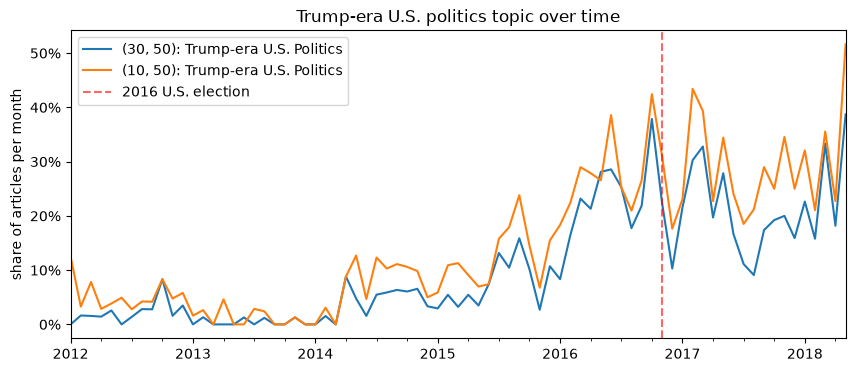

In [13]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def topic_share_over_time(model, metadata, topic_id, freq="ME"):
    """Share of all articles per time period that are assigned to a topic."""
    df_topic = metadata.copy()
    df_topic["date"] = pd.to_datetime(df_topic["date"])
    df_topic["in_topic"] = pd.Series(model.topics_) == topic_id
    return df_topic.set_index("date")["in_topic"].resample(freq).mean()

def plot_topics_with_events(series_specs, event_specs, title, freq="ME"):
    """
    Plot topics' monthly shares as lines on one shared axis, with labeled
    vertical lines for real-world reference events.

    series_specs: list of (model, topic_id, line_label) tuples.
    event_specs: list of (date_string, event_label) tuples.
    """
    fig, ax = plt.subplots(figsize=(10, 4))
    for model, topic_id, line_label in series_specs:
        shares = topic_share_over_time(model, metadata, topic_id=topic_id, freq=freq)
        shares.plot(ax=ax, label=line_label)
    for date, event_label in event_specs:
        ax.axvline(pd.Timestamp(date), color="red", linestyle="--", alpha=0.6, label=event_label)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title(title)
    ax.set_ylabel("share of articles per month")
    ax.set_xlabel("")
    ax.legend()
    plt.show()

# Both shortlisted models' version of the Trump-era politics topic,
# against a labeled marker for the 2016 election.
plot_topics_with_events(
    series_specs=[
        (selected_models[(30, 50)], 1, "(30, 50): Trump-era U.S. Politics"),
        (selected_models[(10, 50)], 0, "(10, 50): Trump-era U.S. Politics"),
    ],
    event_specs=[("2016-11-08", "2016 U.S. election")],
    title="Trump-era U.S. politics topic over time",
)

Both models pick up this topic well. Its share of all articles is low in
2012–2013, rises from 2014 onward, and climbs steeply through 2015 and
2016, the period of the primaries and the campaign. Both models peak in
the same month, October 2016, just before the election (about 38% of all
articles for (30, 50) and 42% for (10, 50)), and politics remains a large
share of coverage throughout the first years of the Trump presidency.
The two lines move almost in parallel, with (10, 50) consistently a few
percentage points higher, which fits its broader, only "partially"
interpretable version of the topic. This check therefore confirms that
both models capture real political news, but it does not discriminate
between them.

One detail deserves a closer look: in November 2016, the month of the
election itself, the share drops sharply in both models (to about 10%
for (30, 50)). With only a few dozen sampled articles per month, this may
be noise. A close reading of the documents from October and November
2016, both those assigned to the politics topic and those that are not,
would show whether election coverage ended up in other topics or among
the outliers, or whether our sample simply contains few political
articles that month.

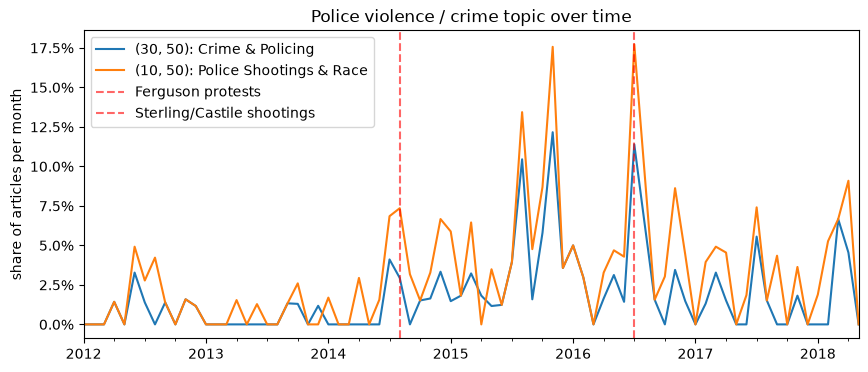

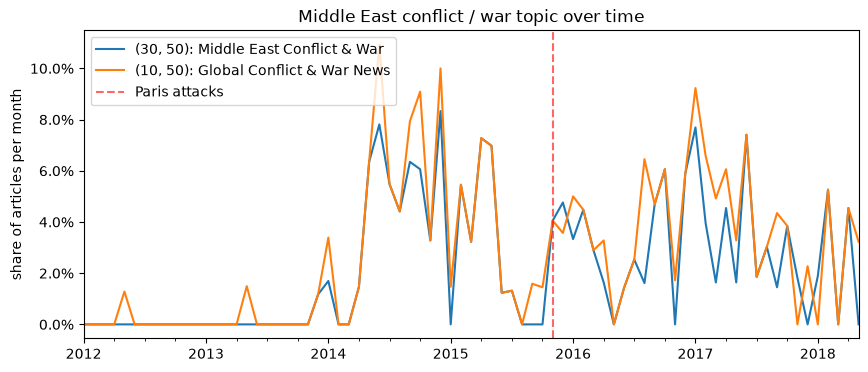

In [14]:
# Police violence: both models' version of the topic, two event markers.
plot_topics_with_events(
    series_specs=[
        (selected_models[(30, 50)], 9, "(30, 50): Crime & Policing"),
        (selected_models[(10, 50)], 6, "(10, 50): Police Shootings & Race"),
    ],
    event_specs=[
        ("2014-08-09", "Ferguson protests"),
        ("2016-07-05", "Sterling/Castile shootings"),
    ],
    title="Police violence / crime topic over time",
)

# Middle East conflict / ISIS: one event marker.
plot_topics_with_events(
    series_specs=[
        (selected_models[(30, 50)], 7, "(30, 50): Middle East Conflict & War"),
        (selected_models[(10, 50)], 7, "(10, 50): Global Conflict & War News"),
    ],
    event_specs=[("2015-11-13", "Paris attacks")],
    title="Middle East conflict / war topic over time",
)

#### Reading the Remaining External Comparisons

**Crime & policing.** Both models' versions ((30, 50) topic 9, (10, 50)
topic 6) move almost in lockstep, with (10, 50) higher at nearly every
peak, again consistent with its broader topic. There is a clear peak
around the Ferguson protests (August 2014; about 7% of all articles for
(10, 50) and 4% for (30, 50)) and a sharp one at the Sterling/Castile
shootings (July 2016; about 18% and 11%). But two spikes in 2015, around
August and November, are just as high, at dates we did not mark. The
topic does seem to capture coverage of police violence, but our
two-event comparison is clearly incomplete. A close reading of the
documents assigned to this topic in those months would show which
events or debates drive the 2015 spikes, and whether they belong to the
same theme. On this comparison, neither model clearly outperforms the
other.

**Middle East conflict.** Both models' topic 7 is almost absent in
2012–2013, rises sharply in 2014 with its largest peaks that year (about
8–11% of all articles), and fluctuates between 0% and 9% afterwards.
Around the Paris attacks (November 2015) the share climbs from near zero
to about 4–5%, a visible but modest rise compared with 2014. A single
date is a poor reference point for an ongoing, multi-year conflict; a
steadier external series, such as monthly conflict-event counts from
ACLED, would fit better.

The near-absence before 2014 is the more interesting finding. The Syrian civil war was already well under
way in 2012–2013, yet neither model finds it as part of this topic. A
close reading of 2012–2013 articles could show whether such coverage is
simply rare in our sample, or whether it was assigned to other topics or
to the outliers.

Together, the three external comparisons show that both models capture
real-world developments, but none clearly discriminates between them.
They also show that external validation is only as informative as the
reference points chosen.

### Who Is Left Out? Checking the Outliers

Every topic-level analysis above ignores the outlier topic (`-1`), and
for our shortlist that is a large part of the corpus: 47.6% of the
documents for (30, 50) and 37.3% for (10, 50). If the outliers were a
random slice of the corpus, this would only cost statistical power. If
they are concentrated in certain sections or periods, every topic-level
result silently inherits that bias. The function below compares the
composition of excluded documents with the full corpus, by HuffPost
section and by publication year. We use it here for the outliers and
again later for merged or disregarded topics.

In [15]:
def dropped_document_bias(model, metadata, dropped_topic_ids, group_col="category", top_n=8):
    """
    Compare the composition of documents excluded from analysis (outliers,
    or topics we disregard or merge) with the full corpus, on a grouping
    column such as `category`. A `ratio` well above 1 means a group is
    over-represented among the excluded documents, and therefore
    under-represented in the topics we analyze.
    """
    df_check = metadata.copy()
    df_check["topic"] = model.topics_
    dropped = df_check[df_check["topic"].isin(dropped_topic_ids)]

    share_dropped = len(dropped) / len(df_check)
    full_dist = df_check[group_col].value_counts(normalize=True)
    dropped_dist = dropped[group_col].value_counts(normalize=True)

    comparison = pd.DataFrame({
        "share_in_full_corpus": full_dist,
        "share_among_dropped": dropped_dist,
    }).fillna(0)
    comparison["ratio"] = (
        comparison["share_among_dropped"] / comparison["share_in_full_corpus"]
    ).replace([float("inf")], float("nan"))

    print(f"Excluding topics {dropped_topic_ids} leaves out "
          f"{len(dropped)} of {len(df_check)} documents ({share_dropped:.1%}).")
    return comparison.sort_values("ratio", ascending=False).head(top_n)


# Outliers by section and by year, for both shortlisted models.
metadata_year = metadata.assign(year=pd.to_datetime(metadata["date"]).dt.year)
for key, model in selected_models.items():
    print(f"\n=== Model {key} ===")
    display(dropped_document_bias(model, metadata, [-1], group_col="category"))
    display(dropped_document_bias(model, metadata_year, [-1], group_col="year"))


=== Model (30, 50) ===
Excluding topics [-1] leaves out 2380 of 5000 documents (47.6%).


,share_in_full_corpus,share_among_dropped,ratio
category,,,
EDUCATION,0.0054,0.010924,2.023031
MONEY,0.0090,0.015546,1.727358
TECH,0.0122,0.020588,1.687560
IMPACT,0.0146,0.023950,1.640382
WOMEN,0.0164,0.026891,1.639680
BUSINESS,0.0284,0.045798,1.612617
SCIENCE,0.0118,0.017647,1.495513
ARTS,0.0094,0.013866,1.475058


Excluding topics [-1] leaves out 2380 of 5000 documents (47.6%).


,share_in_full_corpus,share_among_dropped,ratio
year,,,
2015,0.1680,0.181513,1.080432
2017,0.1446,0.155042,1.072213
2014,0.1552,0.161765,1.042298
2016,0.1576,0.151261,0.959775
2013,0.1792,0.168908,0.942565
2018,0.0422,0.039496,0.935919
2012,0.1532,0.142017,0.927003



=== Model (10, 50) ===
Excluding topics [-1] leaves out 1864 of 5000 documents (37.3%).


,share_in_full_corpus,share_among_dropped,ratio
category,,,
EDUCATION,0.0054,0.011266,2.086314
IMPACT,0.0146,0.028970,1.984244
COLLEGE,0.0046,0.008047,1.749394
SCIENCE,0.0118,0.020386,1.727650
HOME & LIVING,0.0198,0.033262,1.679889
WORLD NEWS,0.0098,0.016094,1.642288
WOMEN,0.0164,0.025215,1.537475
BUSINESS,0.0284,0.043455,1.530103


Excluding topics [-1] leaves out 1864 of 5000 documents (37.3%).


,share_in_full_corpus,share_among_dropped,ratio
year,,,
2015,0.1680,0.179721,1.069768
2014,0.1552,0.159871,1.030098
2013,0.1792,0.181867,1.014883
2017,0.1446,0.145923,1.009148
2012,0.1532,0.149142,0.973509
2016,0.1576,0.145386,0.922502
2018,0.0422,0.038090,0.902610


How to read this: a `ratio` close to 1 for every group means the
outliers look like the corpus as a whole. A ratio well above 1 (say,
above 1.5) flags a section or period the model systematically fails to
assign, and which is therefore under-represented in every topic-level
result.

**Over time**, the outliers are close to random: for both models, every
year's ratio lies between 0.90 and 1.08. The over-time plots above are
therefore not distorted by which documents ended up as outliers.

**By section**, they are not random. In both models, the same kinds of
sections are over-represented among the outliers: EDUCATION, IMPACT,
SCIENCE, WOMEN, and BUSINESS, plus MONEY, TECH, and ARTS in (30, 50) and
COLLEGE, HOME & LIVING, and WORLD NEWS in (10, 50). These are mostly
small sections, so the individual ratios rest on few documents: EDUCATION
has only 27 articles in our sample, nearly all of which (30, 50) leaves
unassigned. Taken together, though, the pattern is clear: neither model
has a topic for these themes, so their articles fall through to the
outliers.

BUSINESS stands out because it is larger (142 articles) and because a
business/economy topic was one of our stated expectations. About 77% of
business articles are outliers in (30, 50), against about 57% in
(10, 50). This largely answers the question raised in "Interpretation:
What the Reading Told Us": business content is not mainly absorbed into
politics; most of it goes unassigned.

For the choice between the two models, the check reveals no different
kind of bias: both leave out the same kinds of content. But (30, 50)
leaves out more of it, which matters for any research question
concerned with business, education, or science coverage.

### Selecting Our Final Model

Pulling the evidence together:

- **Quantitative screening** ranked `(30, 50)` first and `(10, 50)` a
  close second on coherence and diversity. `(30, 50)`'s topics also follow
  the existing categories slightly more closely (category alignment 0.51
  vs. 0.47), which we treat as mild support at most, since the categories
  are not a gold standard.
- **Internal qualitative inspection** found `(30, 50)`'s topics held
  together better on a close read (9 of 12 fully interpretable vs. 9 of
  14).
- **External comparisons** showed that both models capture real-world
  developments, but none of the three discriminated between them.
- **Outliers** favor `(10, 50)`, which leaves 37.3% of the documents
  unassigned against 47.6% for `(30, 50)`. Both leave out the same kinds
  of content (notably business, education, and science), but `(30, 50)`
  leaves out more of it, including about 77% of business articles
  against 57%.

The evidence does not point in one direction. The screening metrics and
our close reading favor `(30, 50)`, the outlier check favors `(10, 50)`,
and the external comparisons do not separate the two. The choice
therefore comes down to what matters most for the purpose of the model.
This tutorial aims at broad, interpretable news themes, so we select
`(30, 50)` with 12 topics: its topics are easier to interpret and label,
which matters most for a model meant to summarize the corpus. The price
is lower coverage: almost half of the documents, and most business,
education, and science coverage, are not assigned to any topic. This
trade-off is a judgment call and should be reported as one. For a
research question about economic news, or one that needs to describe the
whole corpus, `(10, 50)`, or `(30, 50)` combined with BERTopic's outlier
reduction, would be the better choice.

## Model Validation

Having selected `(30, 50)`, we now build the case for why this model is
fit for the purpose set out at the start: producing broad, interpretable,
recognizable news themes from a general-interest outlet's headlines. This
is not proof that the model found the one "true" partition of the
corpus; no such partition exists.

One could object that this is circular: if the final model is validated
with the same evidence that was used to pick it, validation only repeats
the selection. The objection has some force, but it is weaker than it
first seems, for two reasons.

First, part of the standard was set *ex ante*. In "Planning a Validation
Strategy," we wrote down which topics a good model should contain before
fitting anything, and all candidate models were held to that same
standard. Checking the final model against these expectations is not
circular, because the outcome could have gone against us, and partly did:
no business/economy topic emerged.

Second, validation can draw on new evidence that played no role in
selection. Below, we first revisit the ex-ante expectations and the
modeling choices, and then show how to collect such independent evidence
for the final model.

### Theoretical Justification

Revisit the description of a good model from "Planning a Validation
Strategy": individually interpretable topics that include the broad,
recognizable themes we'd expect from a general-interest news outlet. The
`(30, 50)` model largely meets that bar — as the reading above found, 9 of
its 12 topics were fully interpretable and the rest only partially so,
with clear, recognizable topics for U.S. politics, entertainment/style,
sports, travel, and food, among others. It also has a genuine gap against
that same description: no distinct business/economy topic emerged, and most
business articles ended up among the outliers rather than in any topic
(see "Who Is Left Out? Checking the Outliers" above). A validation argument that only reported
the successes and stayed silent about this gap would be less honest, and
less useful to a reader deciding whether to trust the model for their own
purposes, than one that names it directly: for research questions where
business or economic coverage matters, this specific model would need
further work (e.g., a smaller `min_topic_size`, or the hyperparameter
sweep re-run on a larger or more business-heavy sample) before it could be
considered valid for that purpose, even though it validates well against
the broader goal this tutorial set out with.

### Methodological Justification

The modeling choices need a justification of their own. It helps to be
explicit about which choices were made before any model was fit and
which were learned from the sweep, because only the former are
independent of the results.

**Decided before fitting.** We chose BERTopic because it defines a topic
as a semantic cluster of documents in an embedding space rather than a
distribution over co-occurring words, as LDA does. Headlines and
one-sentence descriptions are too short to give a word-co-occurrence
model much to work with, but they carry enough meaning for a pretrained
embedding model. We used the small `all-MiniLM-L6-v2` embedding model to
keep the tutorial fast, removed stopwords only from the topic
representations (not from the texts that are embedded), and worked with
a 5,000-document sample. The ranges of the hyperparameter grid were set
so that the resulting number of topics would stay readable for human
inspection.

**Learned from the sweep.** The screening table shows that, at small
`min_topic_size` values, `n_neighbors=30` produced fewer, broader topics
than `n_neighbors=10` (35 vs. 45 topics at 15, and 22 vs. 29 at 25); at
larger values the difference disappears or even reverses (11 vs. 8 at
75). Favoring more global structure fits our goal of broad news themes,
but this is an observation from the sweep, not a choice we made in
advance, and should be reported as such. Similarly, `min_topic_size=50`
turned out to be the smallest value that kept the number of topics
manageable to read and label.

**Robustness.** The two shortlisted models differ in `n_neighbors`, yet
they agree on all twelve of `(30, 50)`'s themes. The topics therefore do
not hinge on one exact hyperparameter setting. A further, inexpensive
check, which we do not run here, is seed stability: refit the final
configuration with three to five different `random_state` values for
UMAP and check whether the same topics reappear. Topics that only show
up under one seed should be treated with caution.

**Limitations.** The choices above also limit what the model can show:
a small English embedding model, a 5,000-document sample, a single fixed
seed, and no outlier reduction, which leaves almost half of the
documents unassigned.

### New Evidence: Validation Methods Independent of Selection

Several validation methods add evidence that played no part in choosing
the model [@bernhardharrer2026beyond]:

- **Word intrusion** [@chang2009reading]: annotators see a topic's top
  words plus one "intruder" word from another topic. If they reliably
  spot the intruder, the topic's words form a coherent set.
- **Document intrusion**: the same idea applied to documents. Annotators
  see several documents from one topic plus one from another topic and
  pick the odd one out. This tests whether the documents assigned to a
  topic, not just its top words, belong together.
- **Close reading** of the documents in a topic or period, for example
  to answer the open questions from the external comparisons above (the
  November 2016 dip, the 2015 police-violence spikes, the missing
  conflict coverage in 2012–2013).
- **Further external comparisons** with events or statistics that matter
  for your research question, rather than the events used to compare the
  shortlisted models. The plotting function from above can be reused.
- **Manual annotation with the topics as a coding scheme**: annotators
  assign a sample of documents to the topic labels (or "none") without
  seeing the model's assignment. Comparing the two yields formal measures
  such as precision, recall, and F1 for each topic.

Ideally, the annotators are not the person who built and labeled the
model, and at least two annotators code each task, so that agreement
between them can be reported (e.g., Krippendorff's alpha). The cells
below generate the materials for word intrusion, document intrusion,
manual annotation, and close reading for the final model, and score them
once annotated copies exist.

In [16]:
import numpy as np

# The final model and the labels we gave its topics in the labeling worksheet.
final_key = (30, 50)
final_model = selected_models[final_key]
final_labels = (
    labeling_worksheet[labeling_worksheet["model"] == str(final_key)]
    .set_index("topic")["label"]
)
topic_ids = [t for t in sorted(final_model.get_topics()) if t != -1]

# All materials go into one folder. Files ending in "_key.csv" contain the
# answers and must not be shown to annotators.
os.makedirs("validation_tasks", exist_ok=True)
rng = np.random.default_rng(42)


def make_word_intrusion_task(model, topic_ids, n_words=5):
    """
    For each topic: its top `n_words` words plus one intruder, shuffled.
    The intruder is a top word of another topic that is not among this
    topic's own top 10 words.
    """
    top_words = {t: [w for w, _ in model.get_topic(t)][:10] for t in topic_ids}
    tasks, keys = [], []
    for t in topic_ids:
        candidates = {
            w for o in topic_ids if o != t for w in top_words[o][:n_words]
        } - set(top_words[t])
        intruder = str(rng.choice(sorted(candidates)))
        words = top_words[t][:n_words] + [intruder]
        rng.shuffle(words)
        tasks.append({"item": t, "words": ", ".join(words), "chosen_word": ""})
        keys.append({"item": t, "intruder": intruder})
    return pd.DataFrame(tasks), pd.DataFrame(keys)


def make_document_intrusion_task(model, documents, topic_ids, n_docs=3):
    """
    For each topic: `n_docs` randomly drawn documents assigned to it plus
    one intruder document from another topic, shuffled. Annotators enter
    the position (1 to n_docs + 1) of the document that doesn't belong.
    """
    assignments = pd.Series(model.topics_)
    tasks, keys = [], []
    for t in topic_ids:
        own = rng.choice(assignments.index[assignments == t], n_docs, replace=False)
        others = assignments.index[(assignments != t) & (assignments != -1)]
        intruder = rng.choice(others)
        doc_ids = [int(d) for d in own] + [int(intruder)]
        rng.shuffle(doc_ids)
        row = {"item": t}
        for position, d in enumerate(doc_ids, start=1):
            row[f"doc_{position}"] = documents[d]
        row["chosen_doc"] = ""
        tasks.append(row)
        keys.append({"item": t, "intruder_position": doc_ids.index(int(intruder)) + 1})
    return pd.DataFrame(tasks), pd.DataFrame(keys)


def make_annotation_sample(model, documents, labels, topic_ids, n_per_group=15):
    """
    Stratified sample of `n_per_group` documents per topic and from the
    outliers. Annotators assign each document to one label from the
    codebook (or "none") without seeing the model's assignment. The
    `weight` column records how many corpus documents each sampled
    document stands for, so that the scores can correct for stratification.
    """
    assignments = pd.Series(model.topics_)
    rows = []
    for t, group in assignments.groupby(assignments):
        n = min(n_per_group, len(group))
        for d in rng.choice(group.index, n, replace=False):
            rows.append({
                "doc_id": int(d),
                "model_label": labels[t] if t != -1 else "none",
                "weight": len(group) / n,
            })
    key = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
    task = key[["doc_id"]].assign(
        text=[documents[d] for d in key["doc_id"]], annotator_label=""
    )
    codebook = pd.DataFrame({
        "label": [labels[t] for t in topic_ids] + ["none"],
        "top_words": [
            ", ".join(w for w, _ in model.get_topic(t)[:10]) for t in topic_ids
        ] + ["the document fits none of the topics"],
    })
    return task, key, codebook

In [17]:
word_task, word_key = make_word_intrusion_task(final_model, topic_ids)
doc_task, doc_key = make_document_intrusion_task(final_model, documents, topic_ids)
annotation_task, annotation_key, codebook = make_annotation_sample(
    final_model, documents, final_labels, topic_ids
)

materials = {
    "word_intrusion_task": word_task,
    "word_intrusion_key": word_key,
    "document_intrusion_task": doc_task,
    "document_intrusion_key": doc_key,
    "annotation_task": annotation_task,
    "annotation_key": annotation_key,
    "annotation_codebook": codebook,
}
for name, table in materials.items():
    table.to_csv(f"validation_tasks/{name}.csv", index=False)
    print(f"validation_tasks/{name}.csv: {len(table)} rows")

word_task.head()

validation_tasks/word_intrusion_task.csv: 12 rows
validation_tasks/word_intrusion_key.csv: 12 rows
validation_tasks/document_intrusion_task.csv: 12 rows
validation_tasks/document_intrusion_key.csv: 12 rows
validation_tasks/annotation_task.csv: 195 rows
validation_tasks/annotation_key.csv: 195 rows
validation_tasks/annotation_codebook.csv: 13 rows


,item,words,chosen_word
0,0,"new, style, photos, week, fashion, clinton",
1,1,"trump, president, cooking, donald, gop, clinton",
2,2,"photos, summer, new, travel, shooting, world",
3,3,"food, new, cooking, make, recipes, eating",
4,4,"meditation, life, lives, mindfulness, man, things",


Give annotators the `_task.csv` files (and, for manual annotation, the
codebook), never the `_key.csv` files. For each task, annotators fill in
the empty column (`chosen_word`, `chosen_doc`, or `annotator_label`,
using the labels exactly as written in the codebook) and save their copy
under the same name with `-annotated` added, e.g.
`word_intrusion_task-annotated.csv`.

For close reading, the helper below collects all documents a model
assigned to a topic (or to the outliers, `-1`) in a given period. As an
example, we collect the politics topic in October and November 2016 and
the outliers from November 2016, to see where election coverage went
during the dip in the external comparison.

In [18]:
def documents_for_close_reading(model, documents, metadata, topic_id, start, end):
    """All documents assigned to `topic_id` (-1 for outliers) published between `start` and `end`."""
    dates = pd.to_datetime(metadata["date"])
    mask = (pd.Series(model.topics_) == topic_id) & dates.between(start, end)
    return pd.DataFrame({
        "date": dates[mask].dt.date,
        "category": metadata.loc[mask, "category"],
        "text": [documents[i] for i in mask[mask].index],
    })


close_reading = pd.concat([
    documents_for_close_reading(final_model, documents, metadata, 1, "2016-10-01", "2016-11-30")
        .assign(assigned_to="politics topic"),
    documents_for_close_reading(final_model, documents, metadata, -1, "2016-11-01", "2016-11-30")
        .assign(assigned_to="outlier"),
])
close_reading.to_csv("validation_tasks/close_reading_2016-10_to_11.csv", index=False)
close_reading.groupby("assigned_to").size()

assigned_to
outlier           31
politics topic    38
dtype: int64

Once annotated copies exist, the cell below scores them:

- **Word and document intrusion:** the share of topics for which the
  intruder was spotted. Chance level is 1 in 6 for word intrusion (five
  topic words plus one intruder) and 1 in 4 for document intrusion.
- **Manual annotation:** per topic, *precision* is the share of documents
  the model assigned to the topic that the annotator also put there;
  *recall* is the share of documents the annotator put in the topic that
  the model also assigned to it. Documents the model left as outliers
  count against recall, so recall directly reflects the coverage
  trade-off discussed in "Selecting Our Final Model." The scores are
  weighted to correct for the stratified sample.

In [19]:
from sklearn.metrics import precision_recall_fscore_support

def load_annotations(name):
    """Load an annotated task file, or explain what is missing."""
    path = f"validation_tasks/{name}-annotated.csv"
    if not os.path.exists(path):
        print(f"Not annotated yet: fill in and save {path}")
        return None
    return pd.read_csv(path)


answers = load_annotations("word_intrusion_task")
if answers is not None:
    scored = answers.merge(pd.read_csv("validation_tasks/word_intrusion_key.csv"), on="item")
    scored["correct"] = scored["chosen_word"].str.strip() == scored["intruder"]
    print(f"Word intrusion: intruder spotted in {scored['correct'].mean():.0%} of topics")

answers = load_annotations("document_intrusion_task")
if answers is not None:
    scored = answers.merge(pd.read_csv("validation_tasks/document_intrusion_key.csv"), on="item")
    scored["correct"] = scored["chosen_doc"] == scored["intruder_position"]
    print(f"Document intrusion: intruder spotted in {scored['correct'].mean():.0%} of topics")

answers = load_annotations("annotation_task")
if answers is not None:
    scored = answers.merge(pd.read_csv("validation_tasks/annotation_key.csv"), on="doc_id")
    label_list = pd.read_csv("validation_tasks/annotation_codebook.csv")["label"].tolist()
    precision, recall, f1, _ = precision_recall_fscore_support(
        scored["annotator_label"], scored["model_label"],
        labels=label_list, sample_weight=scored["weight"], zero_division=0,
    )
    agree = scored["annotator_label"] == scored["model_label"]
    print(f"Annotation: annotator and model agree on {agree.mean():.0%} of sampled "
          f"documents ({(agree * scored['weight']).sum() / scored['weight'].sum():.0%} weighted)")
    display(pd.DataFrame(
        {"precision": precision, "recall": recall, "f1": f1}, index=label_list
    ).round(2))

Word intrusion: intruder spotted in 100% of topics
Document intrusion: intruder spotted in 100% of topics
Annotation: annotator and model agree on 80% of sampled documents (58% weighted)


,precision,recall,f1
Celebrity & Style News,0.80,0.61,0.70
Trump-era U.S. Politics,0.80,0.45,0.58
Travel & Photos,0.53,0.48,0.51
Food & Cooking,0.87,0.92,0.89
Life Advice & Mindfulness,0.93,0.50,0.65
Parenting,0.80,1.00,0.89
Sports,0.87,1.00,0.93
Middle East Conflict & War (ISIS/Syria),0.60,0.29,0.39
LGBTQ Rights & Issues,1.00,1.00,1.00
Crime & Policing,0.93,0.21,0.35


**A note on the annotations used here.** The annotated files in this
tutorial's repository were coded by one human annotator with the
assistance of a large language model (Claude): the LLM proposed codes,
which the human then checked. 

**How to read the results.** In both intrusion tasks, the intruder was
spotted in all 12 topics, well above chance (1 in 6 and 1 in 4). The
intruders were often easy to spot, though, since many were generic words
such as "new," "week," or "life," so this mainly confirms that the
topics are not incoherent.

Manual annotation is more informative. Annotator and model agree on 80%
of the sampled documents, but only 58% once the stratified sample is
weighted back to the corpus, because most of the corpus consists of
outliers. Two patterns stand out:

- **Precision is mostly high.** Documents the model assigns to a topic
  usually belong there (0.80 or above for most topics, 1.00 for LGBTQ
  issues and weddings). The exceptions are Travel & Photos (0.53), which
  also collects animal stories and photo galleries, and the Middle East
  conflict topic (0.60), whose documents include conflicts elsewhere,
  such as Ukraine or Boko Haram, that the annotator did not count as
  Middle East conflict.
- **Recall is low for several topics, mainly because of the outliers.**
  The annotator placed 10 of the 15 sampled outliers in one of the
  topics, which suggests that roughly two thirds of the unassigned
  documents fit an existing topic. This supports the coverage trade-off
  discussed in "Selecting Our Final Model," and is an argument for
  trying BERTopic's outlier reduction. The recall figures themselves are
  very uncertain, however: each sampled outlier stands for about 159
  corpus documents, so two outliers coded as crime pull that topic's
  recall down to 0.21. For more reliable recall estimates, sample more
  outliers (a larger `n_per_group` for the outlier group).

Because none of this evidence was used to choose the model, it lets the
validation argument rest on more than a restatement of the selection. If
the final model holds up here, with intruders reliably spotted and
reasonable precision for the topics that matter to your research
question, that is independent support for trusting it. If it does not,
that is equally important to know, and to report, before the topics are
used for further analysis.

## Finalizing the Topic Set: Merging and Disregarding Topics

Even once a model is selected and validated, the topics as fitted aren't
necessarily the topics you'll report. Two further researcher decisions are
common at this stage, and both are a legitimate part of using a topic
model, not a way of quietly engineering a cleaner-looking result:

- **Merging.** Two topics can each be individually interpretable and still,
  substantively, be the same underlying theme split across two clusters
  (for example, a topic on campaign politics and a separate one on the
  presidency that a reader would naturally treat as one). Maier and
  colleagues [-@maier2018applying] describe using hierarchical clustering
  on topics' top-word representations to spot such mergeable pairs
  systematically, rather than relying on eyeballing alone.
- **Disregarding.** Some topics survive quantitative screening but still
  turn out, on reading, to be genuinely uninterpretable — no coherent
  theme, just noise that happened to cluster together. None of our final
  `(30, 50)` model's 12 topics fell into this category (see
  "Interpretation: What the Reading Told Us" above), but this is common
  with noisier corpora, less conservative hyperparameters, or a smaller
  `min_topic_size`.

Whatever you decide, these are the researcher's judgment calls to make —
and to report, not automatable steps (see "Reporting" below). But both
come with a specific danger: merging or dropping topics changes which
documents your subsequent analysis actually covers, and if that change
isn't close to random, it can quietly bias what you find. A disregarded
topic that disproportionately contains articles from one time period, one
section, or one underlying group changes the composition of what remains
— and any downstream claim ("topic X increased over time," "topic Y is
associated with Z") silently inherits that bias.

In [ ]:
# Illustrative only: our selected (30, 50) model had no topics we judged
# uninterpretable, so there is nothing to disregard. If, say, topics 5 and
# 11 had come out as unreadable noise, this is how you would check whether
# dropping them removes one kind of content disproportionately, using the
# function defined in "Who Is Left Out? Checking the Outliers"
# dropped_document_bias(selected_models[(30, 50)], metadata, dropped_topic_ids=[5, 11])

If a check like this shows a `ratio` well above or below 1 for some
group, the removal is not random: investigate and report it. The same
applies to merging: check that a merged topic does not combine
substantively different kinds of documents. As with the outliers, the
underlying question is always: who is missing from what I am about to
analyze, and why?

## Reporting

Validation only helps readers if it is reported. Bernhard-Harrer et al.
[-@bernhardharrer2026beyond] identify a "reporting gap" alongside the
validation and standardization gaps: publications often say too little
about how their topic models were validated. At minimum, a write-up
using this tutorial's approach should report:

1. **Preprocessing decisions** and why they were (or weren't) applied —
   for BERTopic, this is a shorter list than for classical methods, but
   it should still be stated explicitly (see "Preprocessing" above).
2. **The hyperparameter search space** actually swept (which parameters,
   which values, and why those bounds), and the final values chosen.
3. **Screening results** for all candidate models, not just the winner —
   the full ranked table, not a single cherry-picked score, so a reader
   can see how close the field was and judge the selection for themselves.
4. **Which selection methods were used and why**, tied back to the
   description of a good model from the planning stage — not just which
   model was picked, but on what combination of evidence.
5. **Validation methods and results**, kept visibly separate from
   selection, including any gaps or limitations found (like the missing
   business/economy topic here) rather than only the successes.
6. **Any topics merged or disregarded**, the criteria used to decide, the
   share of documents affected, and the outcome of a bias check like the
   one above — or an explicit statement that no such check was run, if
   that's the case.
7. **The outlier share** of the final model, the result of an outlier
   composition check, and whether any outlier reduction was applied.
8. **Limitations**, stated plainly — what this validation strategy does
   *not* establish (e.g., we validated for broad thematic interpretability
   for a general audience, not for any specific downstream research
   question), and what a reader with a different purpose in mind should
   check for themselves before reusing this model.

None of this needs to be exhaustive prose. What
matters is that a reader can reconstruct *why* this specific model was
selected and judged valid, not just *that* it was.

## Conclusion

None of the specific choices made along the way — BERTopic over LDA,
these two swept hyperparameters, this particular shortlist, this external
comparison — are meant to be copied wholesale into your own project. What
should transfer is the process: state what a good model would look like
before you start, keep selection and validation conceptually separate,
draw on more than one kind of evidence, and report enough that someone
else could follow your reasoning even where they might have made a
different call. That is what it means to validate an inductive,
unsupervised method like topic modeling in the absence of a gold standard
— not applying a fixed checklist, but making, and defending, a series of
justified choices.

## References